In [ ]:
%pip install lightning

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 27.1 MB/s eta 0:00:00


# Mi primer CNN 👶

Vamos a dejar que la red neuronal aprenda sus propios filtros!

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms
import pytorch_lightning as pl
import matplotlib.pyplot as plt
import numpy as np

# Configuramos una semilla para que, si ejecutas esto varias veces,
# los resultados aleatorios sean siempre los mismos
pl.seed_everything(42)

ModuleNotFoundError: No module named 'pytorch_lightning'

---
## EMNIST

MNIST - numeritos escritos a mano.

EMNIST (*Extended MNIST*) - letras del abecedario (A-Z).

Cada imagen es de **28x28 píxeles** en escala de grises. Es decir, su forma en PyTorch será `[1, 28, 28]` (1 canal de color). Y como son las letras del abecedario en inglés, hay **26 clases** posibles.

In [ ]:
# Preparamos una transformación sencilla: Convertir la imagen cruda a un Tensor de PyTorch
# Y una rotación pequeña porque EMNIST viene rotado 90 grados por defecto
transform_emnist = transforms.Compose([
    lambda img: transforms.functional.rotate(img, -90, expand=True),
    lambda img: transforms.functional.hflip(img),
    transforms.ToTensor()
])

# Descargamos el dataset
full_dataset = torchvision.datasets.EMNIST(
    root='./data',
    split='letters',
    train=True,
    download=True,
    transform=transform_emnist
)

100%|██████████| 562M/562M [00:02<00:00, 202MB/s]


In [ ]:
# EMNIST 'letters' indexa las clases del 1 al 26.
# PyTorch prefiere que las clases vayan de 0 a 25 para trabajar más fácil internamente.
# Así que arreglamos eso restando 1 a cada etiqueta.
print(full_dataset.targets[:10])
full_dataset.targets = full_dataset.targets - 1
print(full_dataset.targets[:10])

tensor([23,  7, 16, 15, 23, 17, 13, 11, 22, 24])
tensor([22,  6, 15, 14, 22, 16, 12, 10, 21, 23])


In [ ]:
# Ahora partimos nuestro dataset
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

# Creamos los DataLoaders (nuestros "meseros" que sirven los datos por 'lotes' o 'batches')
BATCH_SIZE = 64
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"¡Listo! Tenemos {len(train_dataset)} imágenes para entrenar y {len(val_dataset)} para validar.")

¡Listo! Tenemos 99840 imágenes para entrenar y 24960 para validar.


### Cómo se ven los datos? 👀
**Nunca** confíes ciegamente en nada. Siempre imprime unas cuantas imágenes para ver de qué trata el problema al que te enfrentas.

El batch tiene shape: torch.Size([64, 1, 28, 28])
Traducción: [Bbatch_size, Canales, Alto, Ancho]


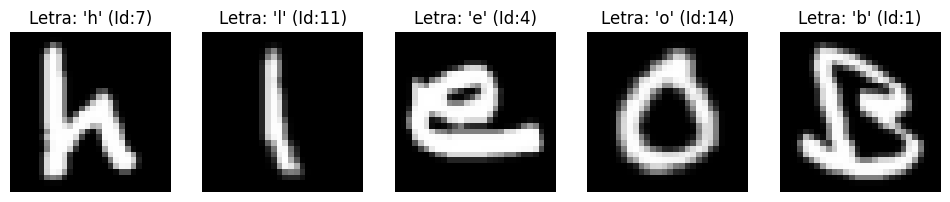

In [ ]:
# Pedimos un batch de imágenes a nuestro DataLoader
images, labels = next(iter(train_loader))

print(f"El batch tiene shape: {images.shape}")
print("Traducción: [Bbatch_size, Canales, Alto, Ancho]")

# Pequeño hack para mapear números a letras (el número 0 es 'A', el 1 es 'B', etc.)
idx_to_letter = {i: chr(ord('a') + i) for i in range(26)}

# Dibujamos los primeros 5 ejemplos del batch
fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i in range(5):
    # Tomamos la imagen 'i' del batch y la aplastamos (squeeze) porque matplotlib quiere matrices [28,28], no [1, 28, 28]
    img_to_plot = images[i].squeeze()
    axes[i].imshow(img_to_plot, cmap='gray')
    clase_num = labels[i].item()
    axes[i].set_title(f"Letra: '{idx_to_letter[clase_num]}' (Id:{clase_num})")
    axes[i].axis('off')
plt.show()

---
## Capas Pool y Flatten

### A) Max Pooling (`nn.MaxPool2d`)
Imagínate que tomas una ventana (por ejemplo de 2x2 píxeles) y solo te quedas con el valor **más alto** (más brillante/fuerte) dentro de esa ventana.
Si haces esto por toda la imagen, estás literalmente **resumiéndola**. Reduces su ancho y alto, quedándote solo con las "características" más resaltantes detectadas por los filtros previos. Además de que hace tus cálculos mucho más rápidos por tener menos píxeles.

### B) Flattening o Aplanamiento (`nn.Flatten`)
Las convoluciones te devuelven tensores en 3D (ej. 32 canales, por una altura y un ancho). Pero al final del día, para decidir si es una 'A' o una 'Z', solemos usar capas de neuronas clásicas (`nn.Linear`) que exigen recibir una **lista plana** de números (1D).
El `Flatten` literalmente rompe el tensor 3D y acomoda todos los números uno tras otro.

---
## Dos bloques

1. **Extractor de Características (Convoluciones):** Donde la red pasa la imagen por filtros, saca bordes, luego junta bordes para hacer curvas, y usa MaxPooling para quedarse con lo mejorcito.
2. **El Clasificador (Capas Lineales o Densas):** Donde toma ese resumen súper denso de características, lo aplana, y a base de sumas y multiplicaciones decide qué letra es.

Vamos a armarlo usando `pl.LightningModule`.

In [ ]:
class LetterClassifier(pl.LightningModule):
    def __init__(self):
        super().__init__()

        # --- PARTE 1: Extractor de Características ---
        #
        # Capa Conv 1: Entra 1 canal (gris), sacamos 16 filtros (buscamos 16 cosas a la vez).
        # Kernel de 3x3 es el estándar moderno. Padding=1 para no encoger la imagen en este paso.
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=3, padding=1)
        # MaxPooling: Resume dimensiones. De 28x28 pasará a 14x14.
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Capa Conv 2: Ahora entran los 16 canales de la capa anterior. 32 filtros nuevos!
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        # Otro MaxPooling: Resume dimensiones. De 14x14 pasará a 7x7.
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        # --- PARTE 2: Aplanado ---
        self.flatten = nn.Flatten()

        # --- PARTE 3: El Clasificador Final ---
        # Matemáticas rápidas:
        # Empezamos con 28x28.
        # Pool1 lo hizo de 14x14.
        # Pool2 lo hizo de 7x7.
        # Y en ese punto tenemos 32 canales (filtros).
        # El tensor 1D será de tamaño: 32 canales * 7 alto * 7 ancho = 1568 numeritos.
        self.fc1 = nn.Linear(32 * 7 * 7, 128) # fc de Fully Connected. Ponemos 128 neuronas ocultas.
        self.fc2 = nn.Linear(128, 26)         # El remate final: 26 neuronas (una para cada letra!)

    def forward(self, x):
        # Aquí le decimos en qué orden pasan los datos por el bloque
        # Primero por la convolución 1, le aplicamos ReLU (para romper la linealidad) y resumimos (Pool)
        x = self.pool1(F.relu(self.conv1(x)))

        # Luego por la convolución 2, aplicamos ReLU y resumimos de nuevo
        x = self.pool2(F.relu(self.conv2(x)))

        # Aplanamos el cubo resultante a un vector largo
        x = self.flatten(x)

        # Lo pasamos por nuestra red neuronal clásica al final
        x = F.relu(self.fc1(x))
        x = self.fc2(x) # De aquí salen nuestras 26 log-probabilidades crudas (logits)
        return x

    # ========= RUTINA DE ENTRENAMIENTO DE LIGHTNING ========= #
    # Nos ahorra hacer los loops 'for epoch' gigantes.

    def training_step(self, batch, batch_idx):
        x, y = batch
        y_hat = self(x) # Llamada automática al 'forward'

        # CrossEntropyLoss es el estándar oro para problemas de clasificación de múltiples clases
        loss = F.cross_entropy(y_hat, y)

        # Opcional: Registrar el error en consola
        self.log('train_loss', loss, prog_bar=True)
        return loss

    def configure_optimizers(self):
        # Adam es un optimizador muy inteligente que ajusta la velocidad de aprendizaje (learning rate) solito
        return torch.optim.Adam(self.parameters(), lr=1e-3)

---
## 4. A entrenarrr

El chiste de Lightning es que no tenemos que programar los detalles complejos del movimiento de tensores a la GPU (tarjeta gráfica) o de iterar manualmente por el DataLoader. Todo se hace mediante un `Trainer`.

In [ ]:
# 1. Instanciamos nuestro flamante modelo recién definido
model = LetterClassifier()

# 2. Creamos al entrenador.
# Le pedimos entrenar por 3 "epochs".
# (Un epoch significa que la red vio TODAS las imágenes del dataset de entrenamiento 1 sola vez)
trainer = pl.Trainer(max_epochs=3, accelerator='auto')

# A darle
trainer.fit(model, train_loader)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:pytorch_lightning.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━┳━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name    ┃ Type      ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ conv1   │ Conv2d    │    160 │ train │     0 │
│ 1 │ pool1   │ MaxPool2d │      0 │ train │     0 │
│ 2 │ conv2   │ Conv2d    │  4.6 K │ train │     0 │
│ 3 │ pool2   │ MaxPool2d │      0 │ train │     0 │
│ 4 │ flatten │ Flatten   │      0 │ train │     0 │
│ 5 │ fc1     │ Linear    │  200 K │ train │     0 │
│ 6 │ fc2     │ Linear    │  3.4 K │ train │     0 │
└───┴─────────┴───────────┴────────┴───────┴───────┘

Trainable params: 208 K                                                                                            
Non-trainable params: 0                                                                                            
Total params: 208 K                                                                                                
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 7                                                                                           
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=3` reached.


---
## 5. Predicciones

Tu red ahora "ya se sabe" el abecedario muy bien. Vamos a agarrar unas cuantas imágenes del **set de validación** (imágenes que la red NUNCA vio al entrenar) y a pedirle que nos diga qué letras cree que son.

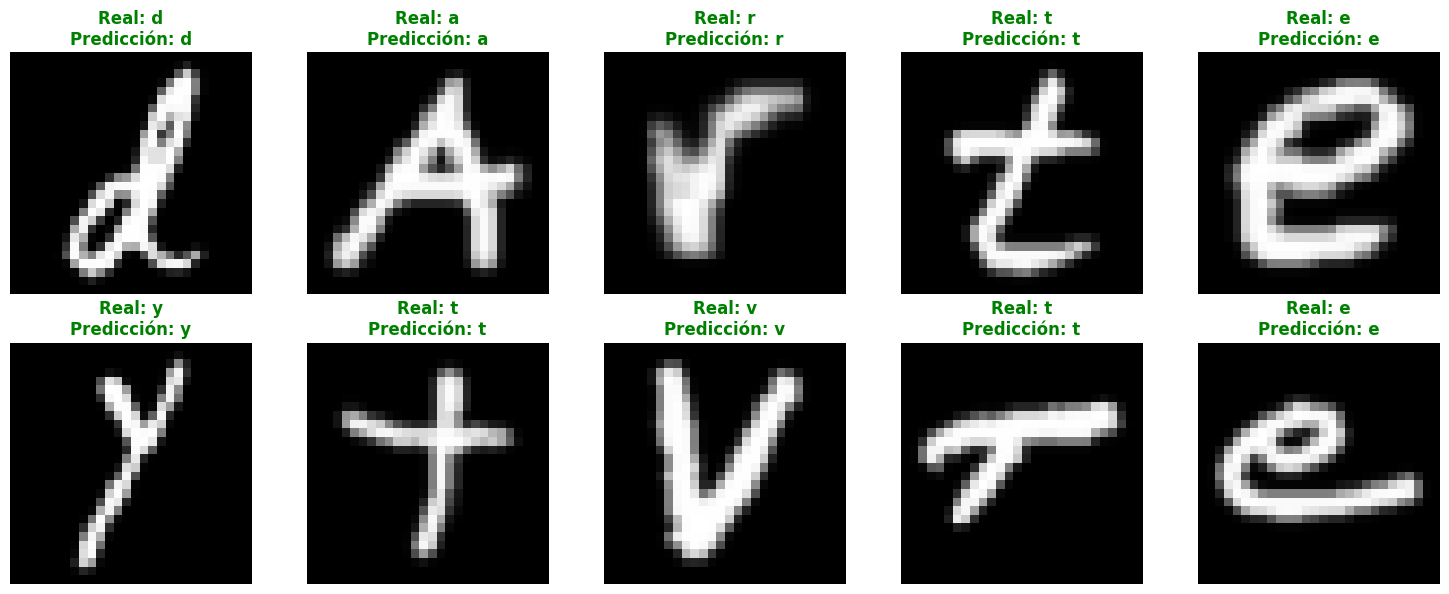

In [ ]:
model.eval() # Modo evaluación (apaga cosas irrelevantes como el Dropout si lo tuviéramos)

# Tomamos un batch de validación
val_images, val_labels = next(iter(val_loader))

with torch.no_grad(): # Le pedimos a PyTorch que no guarde memoria de los gradientes (es más rápido así para predecir)
    # Le pasamos todo el lote de imágenes frescas (¡64 de jalón!) al modelo para que prediga.
    predicciones = model(val_images)
    # Las predicciones son 26 números por imagen. Queremos quedarnos con el número (clase) que tuvo mayor puntaje.
    # El comando torch.argmax nos devuelve el 'índice' de la columna con el número mayor.
    predicciones_clase = torch.argmax(predicciones, dim=1)

# Visualizamos las primeras 10
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i, ax in enumerate(axes.flat):
    img_to_plot = val_images[i].squeeze()

    ax.imshow(img_to_plot, cmap='gray')

    letra_real = idx_to_letter[val_labels[i].item()]
    letra_predicha = idx_to_letter[predicciones_clase[i].item()]

    # Titulamos en verde si atinó, y rojo si falló.
    color = "green" if letra_real == letra_predicha else "red"
    ax.set_title(f"Real: {letra_real}\nPredicción: {letra_predicha}", color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

# 6. Resultados

In [ ]:
all_labels = []
all_preds = []

model.eval() # Set the model to evaluation mode

with torch.no_grad(): # Disable gradient calculation for inference
    for images, labels in val_loader:
        # Make predictions
        outputs = model(images)
        # Get the predicted class (index of the max log-probability)
        predicted_classes = torch.argmax(outputs, dim=1)

        # Store true labels and predictions, moving them to CPU if necessary
        all_labels.append(labels.cpu())
        all_preds.append(predicted_classes.cpu())

# Concatenate all collected labels and predictions into single tensors
all_labels = torch.cat(all_labels)
all_preds = torch.cat(all_preds)

print(f"Collected {len(all_labels)} true labels and {len(all_preds)} predictions.")

Collected 24960 true labels and 24960 predictions.


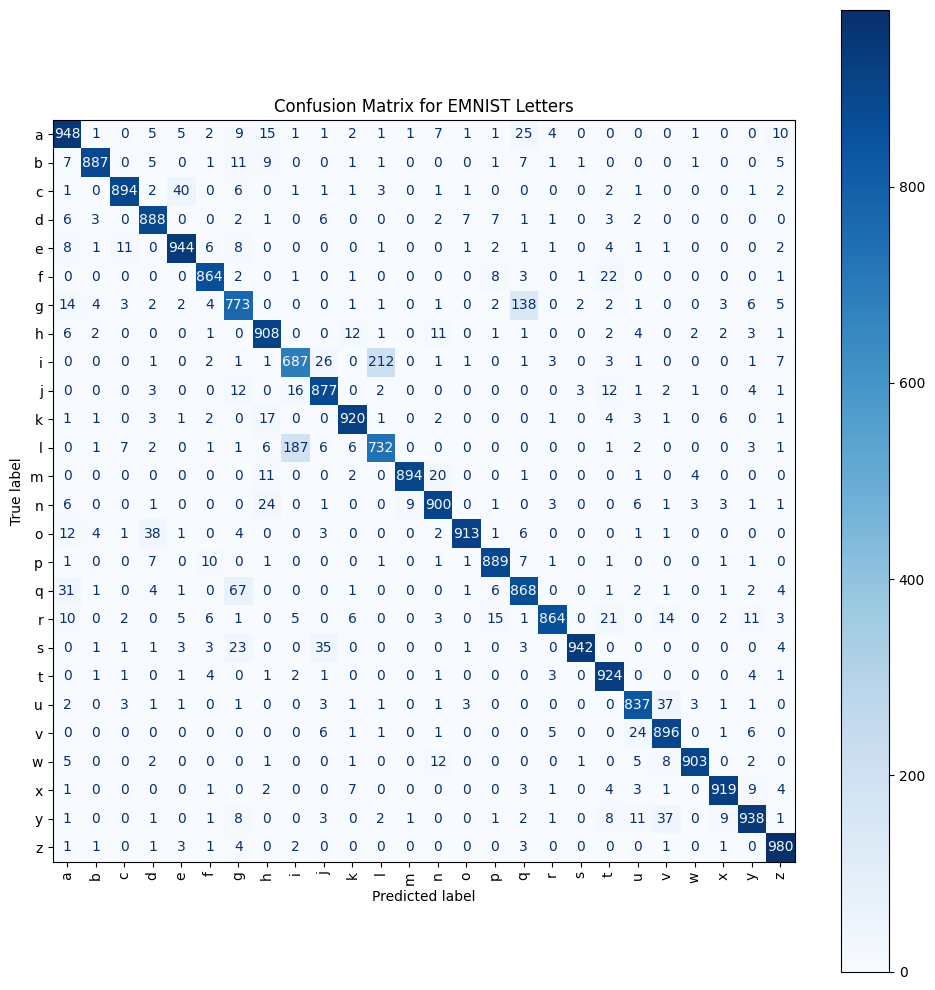

Confusion matrix displayed.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Define class names (a-z) for better readability of the confusion matrix
class_names = [chr(ord('a') + i) for i in range(26)]

# Create and display the confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
ConfusionMatrixDisplay.from_predictions(
    all_labels.numpy(), # Convert tensors to numpy arrays for sklearn
    all_preds.numpy(),
    display_labels=class_names,
    cmap=plt.cm.Blues,
    ax=ax
)
ax.set_title('Confusion Matrix for EMNIST Letters')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print("Confusion matrix displayed.")

In [ ]:
report = classification_report(all_labels.numpy(), all_preds.numpy(), target_names=class_names, output_dict=True)

# Convert the report to a pandas DataFrame for better readability
import pandas as pd
report_df = pd.DataFrame(report).transpose()

print("Classification Report for EMNIST Letters:")
print(report_df)


Classification Report for EMNIST Letters:
              precision    recall  f1-score       support
a              0.893497  0.911538  0.902427   1040.000000
b              0.976872  0.945629  0.960997    938.000000
c              0.968581  0.934169  0.951064    957.000000
d              0.918304  0.955867  0.936709    929.000000
e              0.937438  0.951613  0.944472    992.000000
f              0.950495  0.956811  0.953642    903.000000
g              0.828510  0.801867  0.814971    964.000000
h              0.910732  0.948798  0.929376    957.000000
i              0.761641  0.724684  0.742703    948.000000
j              0.905057  0.938972  0.921703    934.000000
k              0.955348  0.954357  0.954852    964.000000
l              0.762500  0.765690  0.764092    956.000000
m              0.987845  0.958199  0.972797    933.000000
n              0.931677  0.937500  0.934579    960.000000
o              0.981720  0.925025  0.952530    987.000000
p              0.950802  0.964